<a href="https://colab.research.google.com/github/sureshchengaiyan/FDP_demo/blob/main/simple_liner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset
    YearsExperience  Salary
0               1.1   39343
1               1.3   46205
2               1.5   37731
3               2.0   43525
4               2.2   39891
5               2.9   56642
6               3.0   60150
7               3.2   54445
8               3.5   64445
9               3.7   57189
10              4.0   63218
11              4.5   61111
12              5.0   67938
13              5.2   66029
14              5.9   81363
15              6.0   93940
16              6.8   91738
17              7.1   98273
18              7.9  101302
19              8.2  113812
20              8.7  109431
21              9.0  105582
22              9.5  116969
23             10.3  122391

Regression Equation
Salary = 9631.69 × Experience + 25477.68

Actual vs Predicted
   Actual  Predicted
0   64445   59188.60
1   91738   90973.19
2   39343   36072.54
3  101302  101568.05
4   61111   68820.30

Evaluation Metrics
MAE : 3453.4
MSE : 19682916.73
RMSE: 4436.54
R² Score: 0.9605



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


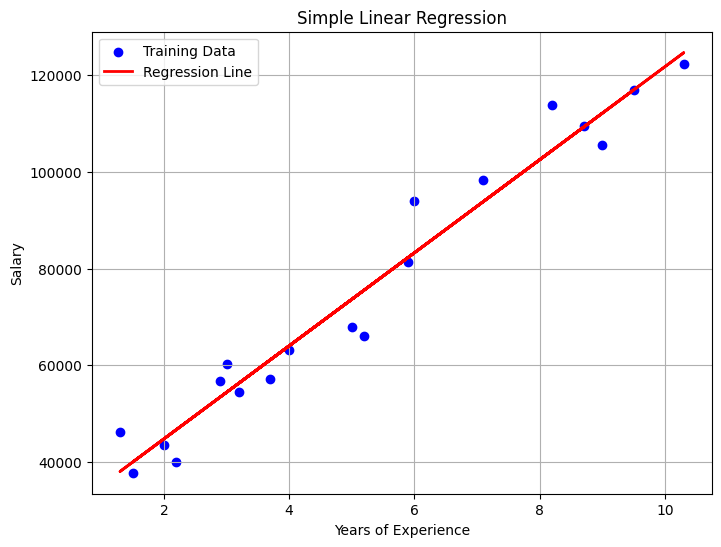

In [1]:
# ==========================================================
# Simple Linear Regression using Dictionary Dataset
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------------------------
# Create Dataset using Dictionary
# ----------------------------------------------------------
data = {
    "YearsExperience": [
        1.1, 1.3, 1.5, 2.0, 2.2,
        2.9, 3.0, 3.2, 3.5, 3.7,
        4.0, 4.5, 5.0, 5.2, 5.9,
        6.0, 6.8, 7.1, 7.9, 8.2,
        8.7, 9.0, 9.5, 10.3
    ],

    "Salary": [
        39343, 46205, 37731, 43525, 39891,
        56642, 60150, 54445, 64445, 57189,
        63218, 61111, 67938, 66029, 81363,
        93940, 91738, 98273, 101302, 113812,
        109431, 105582, 116969, 122391
    ]
}

# Convert Dictionary to DataFrame
df = pd.DataFrame(data)

print("Dataset")
print(df)

# ----------------------------------------------------------
# Independent and Dependent Variables
# ----------------------------------------------------------
X = df[["YearsExperience"]]
y = df["Salary"]

# ----------------------------------------------------------
# Split Dataset
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ----------------------------------------------------------
# Train Model
# ----------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ----------------------------------------------------------
# Regression Equation
# ----------------------------------------------------------
print("\nRegression Equation")
print(f"Salary = {model.coef_[0]:.2f} × Experience + {model.intercept_:.2f}")

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------
y_pred = model.predict(X_test)

print("\nActual vs Predicted")
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.round(2)
})

print(result)

# ----------------------------------------------------------
# Evaluation
# ----------------------------------------------------------
print("\nEvaluation Metrics")
print("MAE :", round(mean_absolute_error(y_test, y_pred), 2))
print("MSE :", round(mean_squared_error(y_test, y_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, y_pred) ** 0.5, 2))
print("R² Score:", round(r2_score(y_test, y_pred), 4))

# ----------------------------------------------------------
# Predict Salary for New Experience
# ----------------------------------------------------------
experience = [[6.5]]
salary = model.predict(experience)

print(f"\nPredicted Salary for {experience[0][0]} years of experience: {salary[0]:.2f}")

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_train, y_train, color="blue", label="Training Data")
plt.plot(X_train, model.predict(X_train), color="red", linewidth=2,
         label="Regression Line")

plt.title("Simple Linear Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)

plt.show()